# Decision Tree

#### Pedro Mauri Mtz - A01029143

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

### Data science

In [3]:
df = pd.read_csv(os.path.join(ROOT, "Datasets", "dataset_DT.csv"), sep=",")
df_copy = df.copy()
df.head()

,Result,Initial Payment,Last Payment,Credit Score,House Number
0,yes,201,10018,250,3046
1,yes,205,10016,395,3044
2,yes,257,10129,109,3251
3,yes,246,10064,324,3137
4,yes,117,10115,496,3094


In [4]:
df.isna().sum()

Result             0
Initial Payment    0
Last Payment       0
Credit Score       0
House Number       0
dtype: int64

In [5]:
df.nunique()

Result               2
Initial Payment    369
Last Payment       917
Credit Score       614
House Number       773
dtype: int64

In [6]:
X = df.drop("Result", axis = 1)
y = df["Result"]

In [7]:
X.shape, y.shape

((1000, 4), (1000,))

### Create datasets

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Decision Tree Classifier

In [9]:
# Create the Decision Tree Classifier model
DT_Model = DecisionTreeClassifier(criterion = "entropy", max_depth = 3, min_samples_split = 5)

#### Training

In [10]:
# Train the model
DT_Model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
y_pred_train_data = DT_Model.predict(x_train)
accuracy_train_data = accuracy_score(y_train, y_pred_train_data)
print(f"Model Accuracy on Training Data: {accuracy_train_data}")

Model Accuracy on Training Data: 0.92625


#### Testing

In [12]:
# Test the model
y_pred = DT_Model.predict(x_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.93


In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[99 10]
 [ 4 87]]


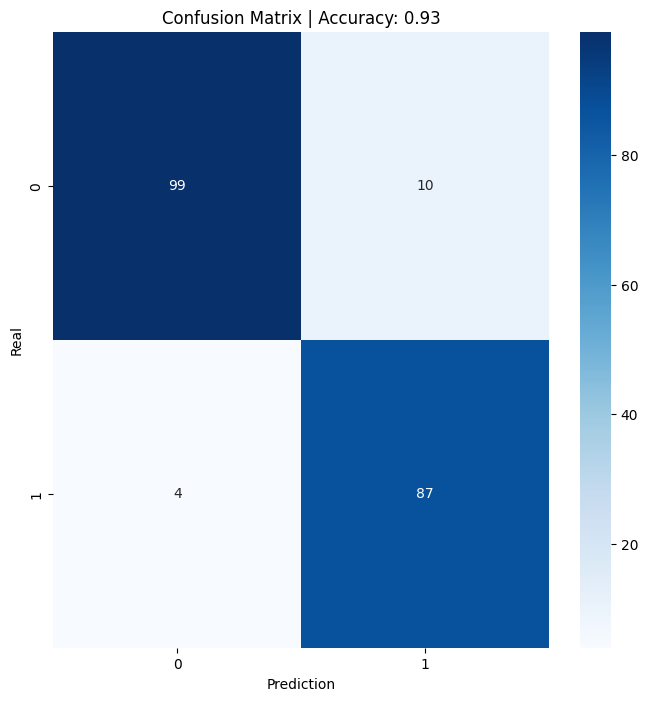

In [15]:
plt.figure(figsize = (8, 8))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.ylabel("Real")
plt.xlabel("Prediction")
plt.title(f"Confusion Matrix | Accuracy: {accuracy}")
plt.show()